# BiomedCLIP 기반 Alzheimer MRI 분류 - Separate Augmentation Refactored

이 노트북은 BiomedCLIP feature caching 단계와 cache 기반 classifier 학습 단계를 분리하고, Alzheimer MRI 이미지에 대해 separate augmentation 전략을 적용합니다.

1차 목표는 성능 향상이 아니라, separate augmentation 전략을 정확히 구현하고 feature caching 구조를 안정화하는 것입니다.

실험 모드는 상단 config의 `TRAIN_FEATURE_MODE`만 바꿔 비교할 수 있습니다.

- Experiment 1: `TRAIN_FEATURE_MODE = "original"`
- Experiment 2: `TRAIN_FEATURE_MODE = "sepaug_3n"`
- Experiment 3: `TRAIN_FEATURE_MODE = "sepaug_4n"`

## Separate Augmentation 전략

본 프로젝트에서는 Alzheimer MRI 이미지에 대해 rotation, shift, zoom을 동시에 적용하는 combined augmentation 대신, 각 변형을 독립적으로 적용하는 separate augmentation 전략을 사용한다.

원본 이미지가 N장일 때 rotation N장, shift N장, zoom N장을 생성하여 총 3N개의 augmented samples를 만들 수 있으며, 원본까지 포함하면 4N개의 학습 데이터를 구성할 수 있다.

이 방식은 의료 영상에서 과도한 복합 변형으로 인한 해부학적 왜곡을 줄이고, 각 변형에 대한 모델의 강건성을 개별적으로 학습시키기 위한 것이다. 이전 Alzheimer MRI 실험에서도 해당 방식이 가장 좋은 성능을 보여 본 실험의 주요 augmentation 전략으로 채택하였다.

## 1. 환경 점검 및 랜덤 Seed 고정

In [1]:
import os
import sys
import time
import math
import random
import shutil
from pathlib import Path
from collections import Counter
from contextlib import contextmanager

import numpy as np
import torch

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python executable : {sys.executable}")
print(f"Python version    : {sys.version}")
print(f"torch version     : {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("GPU name          : CUDA GPU not available")
print(f"device            : {device}")

Python executable : C:\Users\user\anaconda3\envs\alzheimer\python.exe
Python version    : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
torch version     : 2.12.0.dev20260408+cu128
torch.version.cuda: 12.8
cuda available    : True
GPU name          : NVIDIA GeForce RTX 5070
device            : cuda


## 2. Config 및 경로 설정

In [2]:
# Windows 경로 문제를 피하려고 raw string(r"...")을 사용합니다.
DATA_DIR = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data")
TRAIN_DIR = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data\train")
TEST_DIR = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data\test")
CACHE_DIR = Path(r"C:\Users\user\alzheimer\cache_biomedclip_sepaug")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
CLASS_KR = ["정상", "매우 경미한 치매", "경도 치매", "중등도 치매"]

# 비교 실험은 이 값만 바꿔 실행합니다.
# 가능한 값: "original", "sepaug_3n", "sepaug_4n"
TRAIN_FEATURE_MODE = "sepaug_4n"
assert TRAIN_FEATURE_MODE in {"original", "sepaug_3n", "sepaug_4n"}

# Separate augmentation 강도
ROTATION_DEGREES = 10
SHIFT_TRANSLATE = (0.05, 0.05)
ZOOM_SCALE = (0.9, 1.1)
DETERMINISTIC_AUGMENTATION = True

# Feature extraction DataLoader 설정
AUG_EXTRACT_BATCH_SIZE = 64
ORIGINAL_EXTRACT_BATCH_SIZE = 128
NUM_WORKERS = 0  # Windows/Jupyter에서는 0, 2, 4를 비교해 보세요.
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0

# Cache 삭제 여부. 기존 cache를 삭제하려면 True로 바꾼 뒤 이 셀을 다시 실행하세요.
DELETE_EXISTING_CACHE = False

TRAIN_CACHE_PATHS = {
    "original": {
        "features": CACHE_DIR / "train_features_original.pt",
        "labels": CACHE_DIR / "train_labels_original.pt",
        "part_name": "train_original",
    },
    "sepaug_3n": {
        "features": CACHE_DIR / "train_features_sepaug_3n.pt",
        "labels": CACHE_DIR / "train_labels_sepaug_3n.pt",
        "part_name": "train_sepaug_3n",
    },
    "sepaug_4n": {
        "features": CACHE_DIR / "train_features_sepaug_4n.pt",
        "labels": CACHE_DIR / "train_labels_sepaug_4n.pt",
        "part_name": "train_sepaug_4n",
    },
}

TEST_FEAT_PATH = CACHE_DIR / "test_features_original.pt"
TEST_LABEL_PATH = CACHE_DIR / "test_labels_original.pt"
CACHE_PART_DIR = CACHE_DIR / "parts"
CACHE_PART_DIR.mkdir(parents=True, exist_ok=True)

print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"TEST_DIR : {TEST_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")
print(f"TRAIN_FEATURE_MODE: {TRAIN_FEATURE_MODE}")
print("\n[Cache file status]")
for mode, paths in TRAIN_CACHE_PATHS.items():
    print(f"{mode:10s}: {paths['features'].name} -> {'exists' if paths['features'].exists() else 'missing'}")
print(f"{'test':10s}: {TEST_FEAT_PATH.name} -> {'exists' if TEST_FEAT_PATH.exists() else 'missing'}")

if DELETE_EXISTING_CACHE:
    print("\nDELETE_EXISTING_CACHE=True -> 현재 모드의 train cache와 test cache를 삭제합니다.")
    selected_paths = TRAIN_CACHE_PATHS[TRAIN_FEATURE_MODE]
    for path in [selected_paths["features"], selected_paths["labels"], TEST_FEAT_PATH, TEST_LABEL_PATH]:
        if path.exists():
            path.unlink()
            print(f"deleted: {path}")
else:
    print("\n기존 cache를 유지합니다. 삭제하려면 DELETE_EXISTING_CACHE=True로 바꿔 실행하세요.")

for required_dir in [TRAIN_DIR, TEST_DIR]:
    assert required_dir.exists(), f"Directory not found: {required_dir}"

TRAIN_DIR: C:\Users\user\Desktop\alzheimer_dataset\Data\train
TEST_DIR : C:\Users\user\Desktop\alzheimer_dataset\Data\test
CACHE_DIR: C:\Users\user\alzheimer\cache_biomedclip_sepaug
TRAIN_FEATURE_MODE: sepaug_4n

[Cache file status]
original  : train_features_original.pt -> missing
sepaug_3n : train_features_sepaug_3n.pt -> missing
sepaug_4n : train_features_sepaug_4n.pt -> exists
test      : test_features_original.pt -> exists

기존 cache를 유지합니다. 삭제하려면 DELETE_EXISTING_CACHE=True로 바꿔 실행하세요.


## 3. BiomedCLIP 모델 로드

In [3]:
import open_clip
from PIL import Image

MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

print("BiomedCLIP 로딩 중...")
model, preprocess = open_clip.create_model_from_pretrained(MODEL_NAME)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model = model.to(device)
model.eval()

model_device = next(model.parameters()).device
print(f"model parameter device: {model_device}")

# 모델이 실제로 CUDA에 올라가지 않으면 여기서 중단하고 원인을 먼저 확인합니다.
assert model_device.type == "cuda", f"BiomedCLIP model is not on CUDA. Current device: {model_device}"
print("BiomedCLIP이 CUDA에 올라갔습니다.")

C:\Users\user\anaconda3\envs\alzheimer\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BiomedCLIP 로딩 중...


model parameter device: cuda:0
BiomedCLIP이 CUDA에 올라갔습니다.


## 4. Dataset 정의: 원본 추출용 / Separate Augmentation 추출용

In [4]:
from torch.utils.data import Dataset
from torchvision import transforms

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

@contextmanager
def temporary_seed(seed: int):
    """deterministic augmentation을 위해 random state를 잠시 고정합니다."""
    python_state = random.getstate()
    numpy_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        random.seed(seed)
        np.random.seed(seed % (2**32 - 1))
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        yield
    finally:
        random.setstate(python_state)
        np.random.set_state(numpy_state)
        torch.random.set_rng_state(torch_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)

class AlzheimerImageDataset(Dataset):
    """augmentation 없이 원본 이미지만 deterministic하게 읽는 feature extraction dataset입니다."""
    def __init__(self, root_dir: Path, class_names, preprocess, max_per_class=None):
        self.root_dir = Path(root_dir)
        self.class_names = list(class_names)
        self.preprocess = preprocess
        self.samples = []

        for label_idx, class_name in enumerate(self.class_names):
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                print(f"[WARN] 클래스 폴더가 없습니다: {class_dir}")
                continue
            image_paths = sorted(
                p for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            )
            if max_per_class is not None:
                image_paths = image_paths[:max_per_class]
            for image_path in image_paths:
                self.samples.append((image_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.preprocess(image)
        return image, torch.tensor(label, dtype=torch.long)

class SeparateAugmentedMRIDataset(Dataset):
    """각 원본 이미지에 rotation, shift, zoom을 독립적으로 적용하는 dataset입니다.

    include_original=False이면 ["rotation", "shift", "zoom"]을 만들어 3N 구조가 됩니다.
    include_original=True이면 ["original", "rotation", "shift", "zoom"]을 만들어 4N 구조가 됩니다.

    combined augmentation은 기본 실험에서 사용하지 않습니다. 의료 MRI에서는 rotation, shift, zoom을 한 번에
    적용하면 해부학적 구조가 과하게 변형될 수 있으므로, 각 변형을 따로 적용한 sample을 cache합니다.
    """
    def __init__(
        self,
        root_dir: Path,
        preprocess,
        class_names,
        include_original: bool = False,
        deterministic: bool = True,
        seed: int = 42,
        rotation_degrees: float = 10,
        shift_translate=(0.05, 0.05),
        zoom_scale=(0.9, 1.1),
        max_per_class=None,
    ):
        self.root_dir = Path(root_dir)
        self.preprocess = preprocess
        self.class_names = list(class_names)
        self.include_original = include_original
        self.deterministic = deterministic
        self.seed = seed
        self.output_types = ["rotation", "shift", "zoom"]
        if include_original:
            self.output_types = ["original"] + self.output_types

        self.rotation_transform = transforms.RandomRotation(degrees=rotation_degrees)
        self.shift_transform = transforms.RandomAffine(degrees=0, translate=shift_translate)
        self.zoom_transform = transforms.RandomAffine(degrees=0, scale=zoom_scale)

        self.base_samples = []
        for label_idx, class_name in enumerate(self.class_names):
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                print(f"[WARN] 클래스 폴더가 없습니다: {class_dir}")
                continue
            image_paths = sorted(
                p for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            )
            if max_per_class is not None:
                image_paths = image_paths[:max_per_class]
            for image_path in image_paths:
                self.base_samples.append((image_path, label_idx))

    def __len__(self):
        return len(self.base_samples) * len(self.output_types)

    def _apply_augmentation(self, image, aug_type):
        if aug_type == "original":
            return image
        if aug_type == "rotation":
            return self.rotation_transform(image)
        if aug_type == "shift":
            return self.shift_transform(image)
        if aug_type == "zoom":
            return self.zoom_transform(image)
        raise ValueError(f"Unknown augmentation type: {aug_type}")

    def __getitem__(self, idx):
        aug_type_count = len(self.output_types)
        base_idx = idx // aug_type_count
        aug_type_idx = idx % aug_type_count
        aug_type = self.output_types[aug_type_idx]

        image_path, label = self.base_samples[base_idx]
        image = Image.open(image_path).convert("RGB")

        if self.deterministic:
            aug_seed = self.seed + base_idx * 1009 + aug_type_idx * 9176
            with temporary_seed(aug_seed):
                image = self._apply_augmentation(image, aug_type)
        else:
            image = self._apply_augmentation(image, aug_type)

        # augmentation 적용 후 반드시 BiomedCLIP preprocess를 적용합니다.
        image = self.preprocess(image)
        return image, torch.tensor(label, dtype=torch.long)

## 5. Dataset 생성 및 실험 모드 선택

In [5]:
MAX_TRAIN_PER_CLASS = None
MAX_TEST_PER_CLASS = None

train_original_extract_dataset = AlzheimerImageDataset(
    root_dir=TRAIN_DIR,
    class_names=CLASS_NAMES,
    preprocess=preprocess,
    max_per_class=MAX_TRAIN_PER_CLASS,
)

train_sepaug_3n_extract_dataset = SeparateAugmentedMRIDataset(
    root_dir=TRAIN_DIR,
    preprocess=preprocess,
    class_names=CLASS_NAMES,
    include_original=False,
    deterministic=DETERMINISTIC_AUGMENTATION,
    seed=SEED,
    rotation_degrees=ROTATION_DEGREES,
    shift_translate=SHIFT_TRANSLATE,
    zoom_scale=ZOOM_SCALE,
    max_per_class=MAX_TRAIN_PER_CLASS,
)

train_sepaug_4n_extract_dataset = SeparateAugmentedMRIDataset(
    root_dir=TRAIN_DIR,
    preprocess=preprocess,
    class_names=CLASS_NAMES,
    include_original=True,
    deterministic=DETERMINISTIC_AUGMENTATION,
    seed=SEED,
    rotation_degrees=ROTATION_DEGREES,
    shift_translate=SHIFT_TRANSLATE,
    zoom_scale=ZOOM_SCALE,
    max_per_class=MAX_TRAIN_PER_CLASS,
)

# test set은 평가 기준이므로 절대 augmentation하지 않습니다.
test_extract_dataset = AlzheimerImageDataset(
    root_dir=TEST_DIR,
    class_names=CLASS_NAMES,
    preprocess=preprocess,
    max_per_class=MAX_TEST_PER_CLASS,
)

if TRAIN_FEATURE_MODE == "original":
    train_extract_dataset = train_original_extract_dataset
    expected_multiplier = 1.0
elif TRAIN_FEATURE_MODE == "sepaug_3n":
    train_extract_dataset = train_sepaug_3n_extract_dataset
    expected_multiplier = 3.0
elif TRAIN_FEATURE_MODE == "sepaug_4n":
    train_extract_dataset = train_sepaug_4n_extract_dataset
    expected_multiplier = 4.0
else:
    raise ValueError(f"Unknown TRAIN_FEATURE_MODE: {TRAIN_FEATURE_MODE}")

selected_train_cache = TRAIN_CACHE_PATHS[TRAIN_FEATURE_MODE]
TRAIN_FEAT_PATH = selected_train_cache["features"]
TRAIN_LABEL_PATH = selected_train_cache["labels"]
TRAIN_PART_NAME = selected_train_cache["part_name"]

# 선택된 train feature extraction dataset입니다.
# mode가 sepaug_3n 또는 sepaug_4n이면 SeparateAugmentedMRIDataset이 들어갑니다.
train_aug_extract_dataset = train_extract_dataset

original_train_count = len(train_original_extract_dataset)
print(f"원본 train 이미지 수: {original_train_count:,}")
print(f"mode: {TRAIN_FEATURE_MODE}")
print(f"캐싱 대상 수: {len(train_extract_dataset):,}")
print(f"배수: {len(train_extract_dataset) / max(original_train_count, 1):.1f}x")
print(f"예상 배수: {expected_multiplier:.1f}x")
print(f"test 이미지 수: {len(test_extract_dataset):,}")
print(f"train cache path: {TRAIN_FEAT_PATH}")
print(f"test cache path : {TEST_FEAT_PATH}")

print("\n[원본 train 클래스별 이미지 수]")
base_counts = Counter(label for _, label in train_original_extract_dataset.samples)
for idx, name in enumerate(CLASS_NAMES):
    print(f"{name:20s}: {base_counts.get(idx, 0):,}")

원본 train 이미지 수: 69,148
mode: sepaug_4n
캐싱 대상 수: 276,592
배수: 4.0x
예상 배수: 4.0x
test 이미지 수: 17,289
train cache path: C:\Users\user\alzheimer\cache_biomedclip_sepaug\train_features_sepaug_4n.pt
test cache path : C:\Users\user\alzheimer\cache_biomedclip_sepaug\test_features_original.pt

[원본 train 클래스별 이미지 수]
NonDemented         : 53,777
VeryMildDemented    : 10,980
MildDemented        : 4,001
ModerateDemented    : 390


## 6. DataLoader 분리: Feature Caching 전용

In [6]:
from torch.utils.data import DataLoader

def make_extract_loader(dataset, batch_size):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        sampler=None,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
    )

train_original_extract_loader = make_extract_loader(train_original_extract_dataset, ORIGINAL_EXTRACT_BATCH_SIZE)
train_aug_extract_loader = make_extract_loader(
    train_aug_extract_dataset,
    AUG_EXTRACT_BATCH_SIZE if TRAIN_FEATURE_MODE.startswith("sepaug") else ORIGINAL_EXTRACT_BATCH_SIZE,
)
train_extract_loader = train_aug_extract_loader
test_extract_loader = make_extract_loader(test_extract_dataset, ORIGINAL_EXTRACT_BATCH_SIZE)

print("Feature extraction DataLoader 준비 완료")
print(f"train_extract_loader mode: {TRAIN_FEATURE_MODE}")
print(f"batch_size: {train_extract_loader.batch_size}")
print(f"shuffle=False, sampler=None, num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}, persistent_workers={PERSISTENT_WORKERS}")
print(f"test_extract_loader batch_size: {test_extract_loader.batch_size}")

# feature caching 단계에서는 학습용 train_loader나 WeightedRandomSampler가 들어간 loader를 절대 사용하지 않습니다.
# WeightedRandomSampler는 같은 이미지를 여러 번 뽑고 일부 이미지는 누락할 수 있어 cache가 원본 dataset과 1:1로 대응하지 않습니다.
# Separate augmentation은 cache dataset 자체를 3N 또는 4N으로 확장하되, 그 확장된 dataset을 shuffle 없이 순서대로 한 번씩 encode합니다.
# class imbalance sampler는 cache feature를 만든 뒤 classifier 학습 단계에서만 적용합니다.

Feature extraction DataLoader 준비 완료
train_extract_loader mode: sepaug_4n
batch_size: 64
shuffle=False, sampler=None, num_workers=0, pin_memory=True, persistent_workers=False
test_extract_loader batch_size: 128


## 7. DataLoader 속도 측정

In [7]:
def benchmark_dataloader(loader, max_batches=50, warn_below_images_per_sec=100):
    start = time.perf_counter()
    total_images = 0
    batches = 0
    for batches, (images, labels) in enumerate(loader, start=1):
        total_images += images.size(0)
        if batches >= max_batches:
            break
    elapsed = time.perf_counter() - start
    images_per_sec = total_images / max(elapsed, 1e-9)
    print(f"{batches:,}개 batch에서 {total_images:,}장 이미지를 {elapsed:.2f}초 동안 읽었습니다.")
    print(f"DataLoader 처리량: {images_per_sec:.1f} images/s")
    if images_per_sec < warn_below_images_per_sec:
        print("[WARN] DataLoader가 느립니다. GPU 사용률이 낮다면 먼저 DataLoader 병목을 의심하세요.")
        print("       NUM_WORKERS, batch_size, PIL/torchvision augmentation 비용을 비교해 보세요.")
        print("       Windows에서는 NUM_WORKERS를 0, 2, 4로 바꿔 측정하는 것을 권장합니다.")
    return images_per_sec

train_loader_ips = benchmark_dataloader(train_extract_loader, max_batches=50)

50개 batch에서 3,200장 이미지를 14.63초 동안 읽었습니다.
DataLoader 처리량: 218.7 images/s


## 8. 1 Batch GPU 추론 테스트

In [8]:
# 이 셀을 실행하는 동안 nvidia-smi에서 python.exe가 GPU 프로세스로 보여야 합니다.
# DataLoader가 느리면 GPU가 encode_image 입력을 기다리느라 놀 수 있습니다.

images, labels = next(iter(train_extract_loader))
images = images.to(device, non_blocking=True)
print(f"images device: {images.device}")
print(f"model device : {next(model.parameters()).device}")

if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.inference_mode():
    feats = model.encode_image(images)
    feats = feats / feats.norm(dim=-1, keepdim=True)
if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start
images_per_sec = images.size(0) / max(elapsed, 1e-9)

print(f"1 batch size       : {images.size(0)}")
print(f"feature shape      : {tuple(feats.shape)}")
print(f"inference time     : {elapsed:.4f}s")
print(f"GPU inference speed: {images_per_sec:.1f} images/s")

images device: cuda:0
model device : cuda:0
1 batch size       : 64
feature shape      : (64, 512)
inference time     : 0.4534s
GPU inference speed: 141.1 images/s


## 9. Feature Caching 함수

In [9]:
def load_cache_if_exists(feat_path: Path, label_path: Path, name: str):
    if feat_path.exists() and label_path.exists():
        print(f"[{name}] 기존 cache를 찾았습니다. 로드합니다...")
        feats = torch.load(feat_path, map_location="cpu")
        labels = torch.load(label_path, map_location="cpu")
        print(f"[{name}] features shape: {tuple(feats.shape)}")
        print(f"[{name}] labels shape  : {tuple(labels.shape)}")
        return feats, labels
    return None, None

def save_cache_part(part_dir: Path, name: str, part_idx: int, feats_list, labels_list):
    part_dir.mkdir(parents=True, exist_ok=True)
    part_feats = torch.cat(feats_list, dim=0)
    part_labels = torch.cat(labels_list, dim=0)
    feat_part_path = part_dir / f"{name}_features_part_{part_idx:04d}.pt"
    label_part_path = part_dir / f"{name}_labels_part_{part_idx:04d}.pt"
    torch.save(part_feats, feat_part_path)
    torch.save(part_labels, label_part_path)
    print(f"[{name}] part {part_idx:04d} 저장: {tuple(part_feats.shape)}")
    return feat_part_path, label_part_path

def merge_cache_parts(part_dir: Path, name: str, final_feat_path: Path, final_label_path: Path):
    feat_parts = sorted(part_dir.glob(f"{name}_features_part_*.pt"))
    label_parts = sorted(part_dir.glob(f"{name}_labels_part_*.pt"))
    assert len(feat_parts) == len(label_parts), "feature part 파일과 label part 파일 개수가 다릅니다."
    assert feat_parts, f"{name} part 파일을 찾을 수 없습니다: {part_dir}"

    feats = torch.cat([torch.load(p, map_location="cpu") for p in feat_parts], dim=0)
    labels = torch.cat([torch.load(p, map_location="cpu") for p in label_parts], dim=0)
    torch.save(feats, final_feat_path)
    torch.save(labels, final_label_path)
    print(f"[{name}] merge된 cache를 저장했습니다.")
    print(f"[{name}] final features shape: {tuple(feats.shape)}")
    print(f"[{name}] final labels shape  : {tuple(labels.shape)}")
    return feats, labels

def extract_and_cache(
    loader,
    model,
    device,
    feat_path: Path,
    label_path: Path,
    name: str,
    part_dir: Path,
    save_every_batches: int = 100,
    use_part_files: bool = True,
):
    cached_feats, cached_labels = load_cache_if_exists(feat_path, label_path, name)
    if cached_feats is not None:
        return cached_feats, cached_labels

    total_images = len(loader.dataset)
    print(f"[{name}] cache가 없습니다. {total_images:,}장 이미지에서 feature를 추출합니다...")
    print(f"[{name}] 중요: 이 loader는 shuffle=False, sampler=None이어야 합니다.")

    if use_part_files:
        # 최종 cache가 없어서 새로 추출할 때는 같은 split의 이전 part 파일을 정리해 중복 merge를 막습니다.
        for old_part in list(part_dir.glob(f"{name}_features_part_*.pt")) + list(part_dir.glob(f"{name}_labels_part_*.pt")):
            old_part.unlink()

    model.eval()
    all_feats = []
    all_labels = []
    part_feats = []
    part_labels = []
    processed = 0
    start_time = time.perf_counter()
    part_idx = 0

    with torch.inference_mode():
        for batch_idx, (images, labels) in enumerate(loader, start=1):
            images = images.to(device, non_blocking=True)
            feats = model.encode_image(images)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            feats_cpu = feats.cpu()
            labels_cpu = labels.cpu()

            if use_part_files:
                part_feats.append(feats_cpu)
                part_labels.append(labels_cpu)
            else:
                all_feats.append(feats_cpu)
                all_labels.append(labels_cpu)

            processed += labels_cpu.numel()
            elapsed = time.perf_counter() - start_time
            ips = processed / max(elapsed, 1e-9)
            remaining = total_images - processed
            eta_min = (remaining / max(ips, 1e-9)) / 60

            if batch_idx == 1 or batch_idx % 10 == 0 or processed >= total_images:
                print(f"[{name}] {processed:,}/{total_images:,} images | {ips:.1f} images/s | ETA {eta_min:.1f} min")

            if use_part_files and batch_idx % save_every_batches == 0:
                part_idx += 1
                save_cache_part(part_dir, name, part_idx, part_feats, part_labels)
                part_feats, part_labels = [], []

    if use_part_files:
        if part_feats:
            part_idx += 1
            save_cache_part(part_dir, name, part_idx, part_feats, part_labels)
        feats, labels = merge_cache_parts(part_dir, name, feat_path, label_path)
    else:
        feats = torch.cat(all_feats, dim=0)
        labels = torch.cat(all_labels, dim=0)
        torch.save(feats, feat_path)
        torch.save(labels, label_path)
        print(f"[{name}] cache를 저장했습니다.")
        print(f"[{name}] features shape: {tuple(feats.shape)}")
        print(f"[{name}] labels shape  : {tuple(labels.shape)}")

    return feats, labels

## 10. 캐싱 실행

In [10]:
# train cache는 TRAIN_FEATURE_MODE에 따라 original / sepaug_3n / sepaug_4n 중 하나로 저장됩니다.
# test set은 평가 기준이므로 항상 원본 이미지만 cache합니다.
# 절대 학습용 train_loader나 WeightedRandomSampler가 포함된 loader를 feature caching에 사용하지 않습니다.

train_feats, train_labels = extract_and_cache(
    loader=train_extract_loader,
    model=model,
    device=device,
    feat_path=TRAIN_FEAT_PATH,
    label_path=TRAIN_LABEL_PATH,
    name=TRAIN_PART_NAME,
    part_dir=CACHE_PART_DIR,
    save_every_batches=100,
    use_part_files=True,
)

test_feats, test_labels = extract_and_cache(
    loader=test_extract_loader,
    model=model,
    device=device,
    feat_path=TEST_FEAT_PATH,
    label_path=TEST_LABEL_PATH,
    name="test_original",
    part_dir=CACHE_PART_DIR,
    save_every_batches=100,
    use_part_files=True,
)

print("\n[최종 cache shape]")
print(f"TRAIN_FEATURE_MODE: {TRAIN_FEATURE_MODE}")
print(f"train_feats : {tuple(train_feats.shape)}")
print(f"train_labels: {tuple(train_labels.shape)}")
print(f"test_feats  : {tuple(test_feats.shape)}")
print(f"test_labels : {tuple(test_labels.shape)}")

[train_sepaug_4n] 기존 cache를 찾았습니다. 로드합니다...
[train_sepaug_4n] features shape: (276592, 512)
[train_sepaug_4n] labels shape  : (276592,)
[test_original] 기존 cache를 찾았습니다. 로드합니다...
[test_original] features shape: (17289, 512)
[test_original] labels shape  : (17289,)

[최종 cache shape]
TRAIN_FEATURE_MODE: sepaug_4n
train_feats : (276592, 512)
train_labels: (276592,)
test_feats  : (17289, 512)
test_labels : (17289,)


## 11. Cache 기반 Linear Probe 또는 MLP Head 학습

In [11]:
import torch.nn as nn
from torch.utils.data import TensorDataset, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

class LinearProbe(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.classifier(x)

class MLPHead(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden_dim: int = 256, dropout: float = 0.2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

train_cache_dataset = TensorDataset(train_feats.float(), train_labels.long())
test_cache_dataset = TensorDataset(test_feats.float(), test_labels.long())

VAL_FRACTION = 0.15
BATCH_SIZE_CACHE = 256
CACHE_NUM_WORKERS = 0
USE_WEIGHTED_SAMPLER = True
USE_CLASS_WEIGHT = False
HEAD_TYPE = "linear"  # "linear" 또는 "mlp"
EPOCHS = 30
LEARNING_RATE = 1e-3

all_indices = np.arange(len(train_cache_dataset))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=train_labels.cpu().numpy(),
)

cache_train_subset = Subset(train_cache_dataset, train_indices.tolist())
cache_val_subset = Subset(train_cache_dataset, val_indices.tolist())

train_index_tensor = torch.as_tensor(train_indices, dtype=torch.long)
train_subset_labels = train_labels[train_index_tensor].cpu().numpy()
class_counts = np.bincount(train_subset_labels, minlength=len(CLASS_NAMES))
print(f"Train subset 클래스별 개수: {class_counts.tolist()}")

if USE_WEIGHTED_SAMPLER:
    sample_weights = np.array([1.0 / max(class_counts[label], 1) for label in train_subset_labels], dtype=np.float64)
    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_shuffle = False
else:
    train_sampler = None
    train_shuffle = True

train_loader = DataLoader(
    cache_train_subset,
    batch_size=BATCH_SIZE_CACHE,
    sampler=train_sampler,
    shuffle=train_shuffle,
    num_workers=CACHE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    cache_val_subset,
    batch_size=BATCH_SIZE_CACHE,
    shuffle=False,
    num_workers=CACHE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_cache_dataset,
    batch_size=BATCH_SIZE_CACHE,
    shuffle=False,
    num_workers=CACHE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

feature_dim = train_feats.shape[1]
if HEAD_TYPE == "mlp":
    classifier = MLPHead(input_dim=feature_dim, num_classes=len(CLASS_NAMES)).to(device)
else:
    classifier = LinearProbe(input_dim=feature_dim, num_classes=len(CLASS_NAMES)).to(device)

if USE_CLASS_WEIGHT:
    class_weight = len(train_subset_labels) / np.maximum(class_counts, 1)
    class_weight = torch.tensor(class_weight, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)
else:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(classifier.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def evaluate_classifier(model_head, loader, device):
    model_head.eval()
    total_loss = 0.0
    total = 0
    y_true = []
    y_pred = []
    with torch.inference_mode():
        for feats, labels in loader:
            feats = feats.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model_head(feats)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    avg_loss = total_loss / max(total, 1)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc, y_true, y_pred

print(f"Classifier: {classifier.__class__.__name__}")
print(f"feature_dim: {feature_dim}")
print(f"train_loader에서 WeightedRandomSampler 사용: {USE_WEIGHTED_SAMPLER}")
print(f"criterion에서 class_weight 사용: {USE_CLASS_WEIGHT}")

# sampler는 cache feature 학습 단계에서만 적용합니다.
# feature caching 단계에서는 sampler를 쓰지 않았고, 여기서는 feature와 label이 고정되어 있으므로
# 같은 feature를 여러 번 sampling해도 class balancing 의미가 명확합니다.

history = []
for epoch in range(1, EPOCHS + 1):
    classifier.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for feats, labels in train_loader:
        feats = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = classifier(feats)
        loss = criterion(logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * labels.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()
    train_loss = train_loss_sum / max(train_total, 1)
    train_acc = train_correct / max(train_total, 1)
    val_loss, val_acc, _, _ = evaluate_classifier(classifier, val_loader, device)
    test_loss, test_acc, _, _ = evaluate_classifier(classifier, test_loader, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
    })
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f} | test acc {test_acc:.4f} | "
        f"lr {scheduler.get_last_lr()[0]:.6f}"
    )

Train subset 클래스별 개수: [182842, 37332, 13603, 1326]
Classifier: LinearProbe
feature_dim: 512
train_loader에서 WeightedRandomSampler 사용: True
criterion에서 class_weight 사용: False
Epoch 01/30 | train loss 1.1815 acc 0.5288 | val acc 0.6075 | test acc 0.6121 | lr 0.000997
Epoch 02/30 | train loss 1.0232 acc 0.5948 | val acc 0.6476 | test acc 0.6538 | lr 0.000989
Epoch 03/30 | train loss 0.9587 acc 0.6189 | val acc 0.6556 | test acc 0.6622 | lr 0.000976
Epoch 04/30 | train loss 0.9212 acc 0.6350 | val acc 0.6673 | test acc 0.6795 | lr 0.000957
Epoch 05/30 | train loss 0.8953 acc 0.6467 | val acc 0.6705 | test acc 0.6834 | lr 0.000933
Epoch 06/30 | train loss 0.8781 acc 0.6527 | val acc 0.6751 | test acc 0.6882 | lr 0.000905
Epoch 07/30 | train loss 0.8645 acc 0.6592 | val acc 0.6763 | test acc 0.6892 | lr 0.000872
Epoch 08/30 | train loss 0.8539 acc 0.6614 | val acc 0.6723 | test acc 0.6848 | lr 0.000835
Epoch 09/30 | train loss 0.8439 acc 0.6662 | val acc 0.6796 | test acc 0.6940 | lr 0.000794

## 12. 평가: Accuracy, Macro F1, Weighted F1, Confusion Matrix

Experiment mode: sepaug_4n
Accuracy   : 0.7035
Macro F1   : 0.4611
Weighted F1: 0.7455

Classification report
                  precision    recall  f1-score   support

     NonDemented     0.9505    0.7426    0.8338     13445
VeryMildDemented     0.4121    0.5366    0.4662      2745
    MildDemented     0.2784    0.6164    0.3836      1001
ModerateDemented     0.0884    0.8980    0.1610        98

        accuracy                         0.7035     17289
       macro avg     0.4324    0.6984    0.4611     17289
    weighted avg     0.8212    0.7035    0.7455     17289

클래스별 accuracy
NonDemented         : 0.7426 (9984/13445)
VeryMildDemented    : 0.5366 (1473/2745)
MildDemented        : 0.6164 (617/1001)
ModerateDemented    : 0.8980 (88/98)


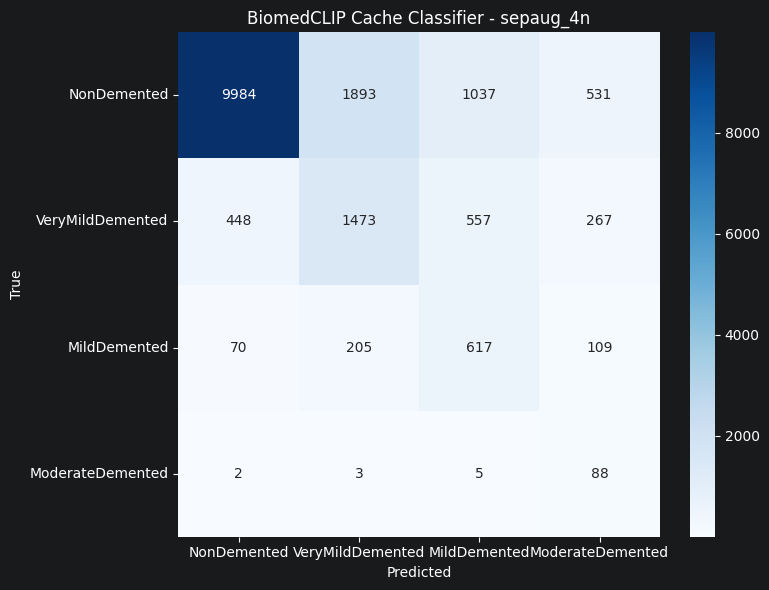

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

_, test_acc, y_true, y_pred = evaluate_classifier(classifier, test_loader, device)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

print(f"Experiment mode: {TRAIN_FEATURE_MODE}")
print(f"Accuracy   : {test_acc:.4f}")
print(f"Macro F1   : {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("\nClassification report")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

print("클래스별 accuracy")
for idx, class_name in enumerate(CLASS_NAMES):
    denom = cm[idx].sum()
    class_acc = cm[idx, idx] / denom if denom > 0 else 0.0
    print(f"{class_name:20s}: {class_acc:.4f} ({cm[idx, idx]}/{denom})")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"BiomedCLIP Cache Classifier - {TRAIN_FEATURE_MODE}")
plt.tight_layout()
plt.show()

## 13. 학습 곡선 확인

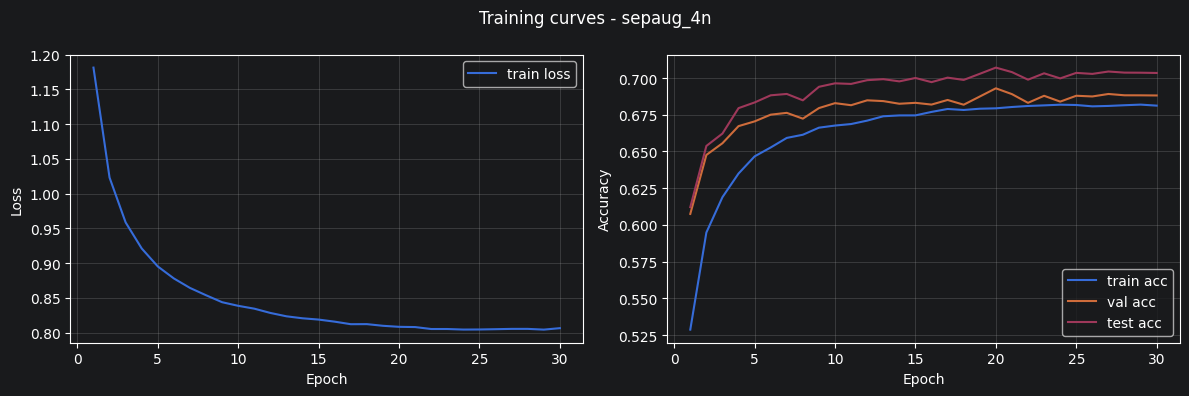

In [13]:
if history:
    epochs = [row["epoch"] for row in history]
    train_losses = [row["train_loss"] for row in history]
    train_accs = [row["train_acc"] for row in history]
    val_accs = [row["val_acc"] for row in history]
    test_accs = [row["test_acc"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_losses, label="train loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, train_accs, label="train acc")
    axes[1].plot(epochs, val_accs, label="val acc")
    axes[1].plot(epochs, test_accs, label="test acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Training curves - {TRAIN_FEATURE_MODE}")
    plt.tight_layout()
    plt.show()
else:
    print("history가 비어 있습니다. 학습 셀을 먼저 실행하세요.")